In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline  

In [2]:
df=pd.read_csv('Travel.csv')
df.head()

,CustomerID,ProdTaken,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfPersonVisiting,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,NumberOfChildrenVisiting,Designation,MonthlyIncome
0,200000,1,41.0,Self Enquiry,3,6.0,Salaried,Female,3,3.0,Deluxe,3.0,Single,1.0,1,2,1,0.0,Manager,20993.0
1,200001,0,49.0,Company Invited,1,14.0,Salaried,Male,3,4.0,Deluxe,4.0,Divorced,2.0,0,3,1,2.0,Manager,20130.0
2,200002,1,37.0,Self Enquiry,1,8.0,Free Lancer,Male,3,4.0,Basic,3.0,Single,7.0,1,3,0,0.0,Executive,17090.0
3,200003,0,33.0,Company Invited,1,9.0,Salaried,Female,2,3.0,Basic,3.0,Divorced,2.0,1,5,1,1.0,Executive,17909.0
4,200004,0,NaN,Self Enquiry,1,8.0,Small Business,Male,2,3.0,Basic,4.0,Divorced,1.0,0,5,1,0.0,Executive,18468.0


In [3]:
df.isnull().sum()

CustomerID                    0
ProdTaken                     0
Age                         226
TypeofContact                25
CityTier                      0
DurationOfPitch             251
Occupation                    0
Gender                        0
NumberOfPersonVisiting        0
NumberOfFollowups            45
ProductPitched                0
PreferredPropertyStar        26
MaritalStatus                 0
NumberOfTrips               140
Passport                      0
PitchSatisfactionScore        0
OwnCar                        0
NumberOfChildrenVisiting     66
Designation                   0
MonthlyIncome               233
dtype: int64

In [4]:
df['TypeofContact'].value_counts()

TypeofContact
Self Enquiry       3444
Company Invited    1419
Name: count, dtype: int64

In [5]:
df['MonthlyIncome']=df['MonthlyIncome'].fillna(df['MonthlyIncome'].mean())

In [6]:
df['Gender'].value_counts()

Gender
Male       2916
Female     1817
Fe Male     155
Name: count, dtype: int64

In [7]:
df['Gender']=df['Gender'].replace('Fe Male','Female')

In [8]:
df['MaritalStatus']=df['MaritalStatus'].replace('Single','Unmarried')

In [9]:
df['Age']=df['Age'].fillna(df['Age'].median())

In [10]:
df.isnull().sum()

CustomerID                    0
ProdTaken                     0
Age                           0
TypeofContact                25
CityTier                      0
DurationOfPitch             251
Occupation                    0
Gender                        0
NumberOfPersonVisiting        0
NumberOfFollowups            45
ProductPitched                0
PreferredPropertyStar        26
MaritalStatus                 0
NumberOfTrips               140
Passport                      0
PitchSatisfactionScore        0
OwnCar                        0
NumberOfChildrenVisiting     66
Designation                   0
MonthlyIncome                 0
dtype: int64

In [11]:
df['TypeofContact']=df.TypeofContact.fillna(df.TypeofContact.mode()[0],inplace=True)
df['DurationOfPitch']=df.DurationOfPitch.fillna(df.DurationOfPitch.mean(),inplace=True)

C:\Users\preet\AppData\Local\Temp\ipykernel_30172\3765072932.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['TypeofContact']=df.TypeofContact.fillna(df.TypeofContact.mode()[0],inplace=True)
C:\Users\preet\AppData\Local\Temp\ipykernel_30172\3765072932.py:2: ChainedAssignmentError: A value is being set on a copy of a DataFrame 

In [12]:
df['NumberOfFollowups']=df['NumberOfFollowups'].fillna(df['NumberOfFollowups'].mode()[0],inplace=True)
df['PreferredPropertyStar']=df['PreferredPropertyStar'].fillna(df['PreferredPropertyStar'].mode()[0],inplace=True)
df['NumberOfTrips']=df['NumberOfTrips'].fillna(df['NumberOfTrips'].median(),inplace=True)
df['NumberOfChildrenVisiting']=df['NumberOfChildrenVisiting'].fillna(df['NumberOfChildrenVisiting'].median(),inplace=True)

C:\Users\preet\AppData\Local\Temp\ipykernel_30172\1732615504.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['NumberOfFollowups']=df['NumberOfFollowups'].fillna(df['NumberOfFollowups'].mode()[0],inplace=True)
C:\Users\preet\AppData\Local\Temp\ipykernel_30172\1732615504.py:2: ChainedAssignmentError: A value is being set on a co

In [13]:
df['Totalvisit']=df['NumberOfPersonVisiting']+df['NumberOfChildrenVisiting']

In [14]:
df.drop({'NumberOfPersonVisiting','NumberOfChildrenVisiting'},axis=1,inplace=True)

In [15]:
df.head()

,CustomerID,ProdTaken,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,Designation,MonthlyIncome,Totalvisit
0,200000,1,41.0,Self Enquiry,3,6.0,Salaried,Female,3.0,Deluxe,3.0,Unmarried,1.0,1,2,1,Manager,20993.0,3.0
1,200001,0,49.0,Company Invited,1,14.0,Salaried,Male,4.0,Deluxe,4.0,Divorced,2.0,0,3,1,Manager,20130.0,5.0
2,200002,1,37.0,Self Enquiry,1,8.0,Free Lancer,Male,4.0,Basic,3.0,Unmarried,7.0,1,3,0,Executive,17090.0,3.0
3,200003,0,33.0,Company Invited,1,9.0,Salaried,Female,3.0,Basic,3.0,Divorced,2.0,1,5,1,Executive,17909.0,3.0
4,200004,0,36.0,Self Enquiry,1,8.0,Small Business,Male,3.0,Basic,4.0,Divorced,1.0,0,5,1,Executive,18468.0,2.0


In [16]:
df.drop('CustomerID',axis=1,inplace=True)

In [17]:
num_features=[feature for feature in df.columns if df[feature].dtype != 'string']
print('numerical features:',len(num_features))
cat_features=[feature for feature in df.columns if df[feature].dtype == 'string']
print('categorical features:',len(cat_features))
discrete_features=[feature for feature in num_features if len(df[feature].unique())<25]
print('discrete features:',len(discrete_features))
continuous_features=[feature for feature in num_features if len(df[feature].unique())>=25]
print('continuous features:',len(continuous_features))

numerical features: 12
categorical features: 6
discrete features: 9
continuous features: 3


In [18]:
from sklearn.model_selection import train_test_split
x=df.drop('ProdTaken',axis=1)
y=df['ProdTaken']

In [19]:
x

,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,Designation,MonthlyIncome,Totalvisit
0,41.0,Self Enquiry,3,6.0,Salaried,Female,3.0,Deluxe,3.0,Unmarried,1.0,1,2,1,Manager,20993.0,3.0
1,49.0,Company Invited,1,14.0,Salaried,Male,4.0,Deluxe,4.0,Divorced,2.0,0,3,1,Manager,20130.0,5.0
2,37.0,Self Enquiry,1,8.0,Free Lancer,Male,4.0,Basic,3.0,Unmarried,7.0,1,3,0,Executive,17090.0,3.0
3,33.0,Company Invited,1,9.0,Salaried,Female,3.0,Basic,3.0,Divorced,2.0,1,5,1,Executive,17909.0,3.0
4,36.0,Self Enquiry,1,8.0,Small Business,Male,3.0,Basic,4.0,Divorced,1.0,0,5,1,Executive,18468.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4883,49.0,Self Enquiry,3,9.0,Small Business,Male,5.0,Deluxe,4.0,Unmarried,2.0,1,1,1,Manager,26576.0,4.0
4884,28.0,Company Invited,1,31.0,Salaried,Male,5.0,Basic,3.0,Unmarried,3.0,1,3,1,Executive,21212.0,6.0
4885,52.0,Self Enquiry,3,17.0,Salaried,Female,4.0,Standard,4.0,Married,7.0,0,1,1,Senior Manager,31820.0,7.0
4886,19.0,Self Enquiry,3,16.0,Small Business,Male,4.0,Basic,3.0,Unmarried,3.0,0,5,0,Executive,20289.0,5.0


In [20]:
y

0       1
1       0
2       1
3       0
4       0
       ..
4883    1
4884    1
4885    1
4886    1
4887    1
Name: ProdTaken, Length: 4888, dtype: int64

In [21]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)


In [22]:
### create column transformer with 3 type of transformers
cat_features=x.select_dtypes(include='string').columns
num_features=x.select_dtypes(exclude='string').columns

In [23]:
from sklearn.preprocessing import OneHotEncoder,StandardScaler
from sklearn.compose import ColumnTransformer

num_transformer=StandardScaler()
OHE_transformer=OneHotEncoder(drop='first')

In [24]:
preprocessor=ColumnTransformer(
     [
        ("OneHotEncoder",OHE_transformer,cat_features),
        ("StandardScaler",num_transformer,num_features)
     ]
)

In [25]:
x_train=preprocessor.fit_transform(x_train)

In [26]:
print(type(x_train))


<class 'numpy.ndarray'>


In [27]:
x_test=preprocessor.transform(x_test)
x_test

array([[ 0.        ,  0.        ,  0.        , ..., -1.2771941 ,
        -0.75006398, -0.77415132],
       [ 1.        ,  0.        ,  0.        , ..., -1.2771941 ,
        -0.68287672, -0.06526803],
       [ 1.        ,  0.        ,  0.        , ...,  0.78296635,
        -0.43297058, -0.77415132],
       ...,
       [ 0.        ,  1.        ,  0.        , ...,  0.78296635,
         0.67933064,  0.64361526],
       [ 1.        ,  0.        ,  0.        , ...,  0.78296635,
         0.00210088, -0.77415132],
       [ 1.        ,  1.        ,  0.        , ...,  0.78296635,
        -0.45828476,  2.06138184]], shape=(978, 26))

In [28]:

pd.DataFrame(x_train)

,0,1,2,3,4,5,6,7,8,9,...,16,17,18,19,20,21,22,23,24,25
0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,...,-0.721400,-1.039854,1.284279,-0.725271,-0.127737,-0.632399,0.679690,0.782966,-0.394333,-0.774151
1,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,...,-0.721400,0.674704,0.282777,-0.725271,1.511598,-0.632399,0.679690,0.782966,-0.471989,0.643615
2,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-0.721400,-1.039854,0.282777,1.771041,0.418708,-0.632399,0.679690,0.782966,-0.257104,-0.065268
3,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,...,-0.721400,-1.039854,1.284279,-0.725271,-0.127737,-0.632399,1.408395,-1.277194,0.202168,-0.065268
4,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-0.721400,2.389261,-1.720227,-0.725271,1.511598,-0.632399,-0.049015,-1.277194,-0.036509,2.061382
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3905,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,...,-0.721400,-0.672449,1.284279,-0.725271,-0.674182,-0.632399,-1.506426,0.782966,-0.549264,0.643615
3906,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,1.455047,-0.917385,-0.718725,1.771041,-1.220627,-0.632399,1.408395,0.782966,1.520028,-0.065268
3907,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.455047,1.531982,0.282777,-0.725271,2.058043,-0.632399,-0.777720,0.782966,-0.372635,0.643615
3908,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,...,1.455047,1.776919,1.284279,-0.725271,-0.127737,-0.632399,-1.506426,0.782966,-0.264717,0.643615


In [29]:
%pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [31]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier,AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report,ConfusionMatrixDisplay, \
                            precision_score, recall_score, f1_score, roc_auc_score,roc_curve 
models={
    "Logisitic Regression":LogisticRegression(),
    "Decision Tree":DecisionTreeClassifier(),
    "Random Forest":RandomForestClassifier(),
    "Gradient Boost":GradientBoostingClassifier(),
    "Adaboost":AdaBoostClassifier(),
    "Xgboost":XGBClassifier()
}
for i in range(len(list(models))):
    model = list(models.values())[i]
    model.fit(x_train, y_train) # Train model

    # Make predictions
    y_train_pred = model.predict(x_train)
    y_test_pred = model.predict(x_test)

    # Training set performance
    model_train_accuracy = accuracy_score(y_train, y_train_pred) # Calculate Accuracy
    model_train_f1 = f1_score(y_train, y_train_pred, average='weighted') # Calculate F1-score
    model_train_precision = precision_score(y_train, y_train_pred) # Calculate Precision
    model_train_recall = recall_score(y_train, y_train_pred) # Calculate Recall
    model_train_rocauc_score = roc_auc_score(y_train, y_train_pred)


    # Test set performance
    model_test_accuracy = accuracy_score(y_test, y_test_pred) # Calculate Accuracy
    model_test_f1 = f1_score(y_test, y_test_pred, average='weighted') # Calculate F1-score
    model_test_precision = precision_score(y_test, y_test_pred) # Calculate Precision
    model_test_recall = recall_score(y_test, y_test_pred) # Calculate Recall
    model_test_rocauc_score = roc_auc_score(y_test, y_test_pred) #Calculate Roc


    print(list(models.keys())[i])
    
    print('Model performance for Training set')
    print("- Accuracy: {:.4f}".format(model_train_accuracy))
    print('- F1 score: {:.4f}'.format(model_train_f1))
    
    print('- Precision: {:.4f}'.format(model_train_precision))
    print('- Recall: {:.4f}'.format(model_train_recall))
    print('- Roc Auc Score: {:.4f}'.format(model_train_rocauc_score))

    
    
    print('----------------------------------')
    
    print('Model performance for Test set')
    print('- Accuracy: {:.4f}'.format(model_test_accuracy))
    print('- F1 score: {:.4f}'.format(model_test_f1))
    print('- Precision: {:.4f}'.format(model_test_precision))
    print('- Recall: {:.4f}'.format(model_test_recall))
    print('- Roc Auc Score: {:.4f}'.format(model_test_rocauc_score))

    
    print('='*35)
    print('\n')

Logisitic Regression
Model performance for Training set
- Accuracy: 0.8453
- F1 score: 0.8192
- Precision: 0.6975
- Recall: 0.3004
- Roc Auc Score: 0.6353
----------------------------------
Model performance for Test set
- Accuracy: 0.8364
- F1 score: 0.8087
- Precision: 0.6914
- Recall: 0.2932
- Roc Auc Score: 0.6307


Decision Tree
Model performance for Training set
- Accuracy: 1.0000
- F1 score: 1.0000
- Precision: 1.0000
- Recall: 1.0000
- Roc Auc Score: 1.0000
----------------------------------
Model performance for Test set
- Accuracy: 0.9223
- F1 score: 0.9213
- Precision: 0.8212
- Recall: 0.7696
- Roc Auc Score: 0.8645


Random Forest
Model performance for Training set
- Accuracy: 1.0000
- F1 score: 1.0000
- Precision: 1.0000
- Recall: 1.0000
- Roc Auc Score: 1.0000
----------------------------------
Model performance for Test set
- Accuracy: 0.9325
- F1 score: 0.9279
- Precision: 0.9630
- Recall: 0.6806
- Roc Auc Score: 0.8371


Gradient Boost
Model performance for Training se

In [34]:
from sklearn.model_selection import GridSearchCV
params={
    'max_depth': [5, 8, 15, None,10],
    'max_features': [5, 'auto', 7],
    'min_samples_split':[2,8,15,18],
    'n_estimators':[100,200,500,1000]
}
adaboost_param={
    'n_estimators':[50,60,70,80],
    'algorithm':['SAMME','SAMME.R']
}
gradient_params={
    "loss":['log_loss','deviance','exponential'],
    "criterion":['friedman_mse','squared_error','mse'],
    "min_samples_split":[2,8,15,20],
    "max_depth":[5,8,15,None,10]
}
xg_boost_params={
    "learning rate":[0.1,0.01],
    "max_depth":[5,8,12,20,30],
    "n_estimators":[100,200,300],
    "colsample_bytree":[0.5,0.8,1,0.3,0.4]
}

In [35]:
randomcv_model=[
    ("RF",RandomForestClassifier(),params),
    ("AB",AdaBoostClassifier(),adaboost_param),
    ("GB",GradientBoostingClassifier(),gradient_params),
    ("Xg",XGBClassifier(),xg_boost_params)
]

In [36]:
randomcv_model

[('RF',
  RandomForestClassifier(),
  {'max_depth': [5, 8, 15, None, 10],
   'max_features': [5, 'auto', 7],
   'min_samples_split': [2, 8, 15, 18],
   'n_estimators': [100, 200, 500, 1000]}),
 ('AB',
  AdaBoostClassifier(),
  {'n_estimators': [50, 60, 70, 80], 'algorithm': ['SAMME', 'SAMME.R']}),
 ('GB',
  GradientBoostingClassifier(),
  {'loss': ['log_loss', 'deviance', 'exponential'],
   'criterion': ['friedman_mse', 'squared_error', 'mse'],
   'min_samples_split': [2, 8, 15, 20],
   'max_depth': [5, 8, 15, None, 10]}),
 ('Xg',
  XGBClassifier(base_score=None, booster=None, callbacks=None,
                colsample_bylevel=None, colsample_bynode=None,
                colsample_bytree=None, device=None, early_stopping_rounds=None,
                enable_categorical=False, eval_metric=None, feature_types=None,
                feature_weights=None, gamma=None, grow_policy=None,
                importance_type=None, interaction_constraints=None,
                learning_rate=None, max_b

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
model_params={}
for name,model,params in randomcv_model:
    random=RandomizedSearchCV(estimator=model,param_distributions=params,n_iter=10,cv=3,verbose=2,n_jobs=-1)
    random.fit(x_train,y_train)
    model_params[name]=random.best_params_

for model_name in model_params:
    print("best for model ",model_name)
    print("best parameters: ",model_params[model_name])


Fitting 3 folds for each of 10 candidates, totalling 30 fits


c:\Users\preet\anaconda3\envs\practise_env\Lib\site-packages\sklearn\model_selection\_validation.py:516: FitFailedWarning: 
15 fits failed out of a total of 30.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
2 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\preet\anaconda3\envs\practise_env\Lib\site-packages\sklearn\model_selection\_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\preet\anaconda3\envs\practise_env\Lib\site-packages\sklearn\base.py", line 1358, in wrapper
    estimator._validate_params()
  File "c:\Users\preet\anaconda3\envs\practise_env\Lib\site-packages\sklearn\base.py", line 471, in _validate_params
    validate_par

In [ ]:
models={
    "Random Forest":RandomForestClassifier(n_estimators=500,min_samples_split=8,max_features=7,max_depth=15),
    "Adaboost":AdaBoostClassifier(n_estimators=80,algorithm='SAMME'),
    "Gradient Boosting":GradientBoostingClassifier(min_samples_split=2,max_depth=10,loss='log_loss',criterion='friedman_mse'),
    ("Xg",XGBClassifier())

}
for i in range(len(list(models))):
    model = list(models.values())[i]
    model.fit(x_train, y_train) # Train model

    # Make predictions
    y_train_pred = model.predict(x_train)
    y_test_pred = model.predict(x_test)

    # Training set performance
    model_train_accuracy = accuracy_score(y_train, y_train_pred) # Calculate Accuracy
    model_train_f1 = f1_score(y_train, y_train_pred, average='weighted') # Calculate F1-score
    model_train_precision = precision_score(y_train, y_train_pred) # Calculate Precision
    model_train_recall = recall_score(y_train, y_train_pred) # Calculate Recall
    model_train_rocauc_score = roc_auc_score(y_train, y_train_pred)


    # Test set performance
    model_test_accuracy = accuracy_score(y_test, y_test_pred) # Calculate Accuracy
    model_test_f1 = f1_score(y_test, y_test_pred, average='weighted') # Calculate F1-score
    model_test_precision = precision_score(y_test, y_test_pred) # Calculate Precision
    model_test_recall = recall_score(y_test, y_test_pred) # Calculate Recall
    model_test_rocauc_score = roc_auc_score(y_test, y_test_pred) #Calculate Roc


    print(list(models.keys())[i])
    
    print('Model performance for Training set')
    print("- Accuracy: {:.4f}".format(model_train_accuracy))
    print('- F1 score: {:.4f}'.format(model_train_f1))
    
    print('- Precision: {:.4f}'.format(model_train_precision))
    print('- Recall: {:.4f}'.format(model_train_recall))
    print('- Roc Auc Score: {:.4f}'.format(model_train_rocauc_score))

    
    
    print('----------------------------------')
    
    print('Model performance for Test set')
    print('- Accuracy: {:.4f}'.format(model_test_accuracy))
    print('- F1 score: {:.4f}'.format(model_test_f1))
    print('- Precision: {:.4f}'.format(model_test_precision))
    print('- Recall: {:.4f}'.format(model_test_recall))
    print('- Roc Auc Score: {:.4f}'.format(model_test_rocauc_score))

    
    print('='*35)
    print('\n')

Random Forest
Model performance for Training set
- Accuracy: 0.9788
- F1 score: 0.9783
- Precision: 0.9939
- Recall: 0.8916
- Roc Auc Score: 0.9452
----------------------------------
Model performance for Test set
- Accuracy: 0.9059
- F1 score: 0.8964
- Precision: 0.9304
- Recall: 0.5602
- Roc Auc Score: 0.7750




c:\Users\preet\anaconda3\envs\practise_env\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(


Adaboost
Model performance for Training set
- Accuracy: 0.8509
- F1 score: 0.8232
- Precision: 0.7552
- Recall: 0.2963
- Roc Auc Score: 0.6371
----------------------------------
Model performance for Test set
- Accuracy: 0.8333
- F1 score: 0.8006
- Precision: 0.7000
- Recall: 0.2565
- Roc Auc Score: 0.6149


Gradient Boosting
Model performance for Training set
- Accuracy: 1.0000
- F1 score: 1.0000
- Precision: 1.0000
- Recall: 1.0000
- Roc Auc Score: 1.0000
----------------------------------
Model performance for Test set
- Accuracy: 0.9540
- F1 score: 0.9522
- Precision: 0.9679
- Recall: 0.7906
- Roc Auc Score: 0.8921




Text(0.5, 1.0, 'ROC')

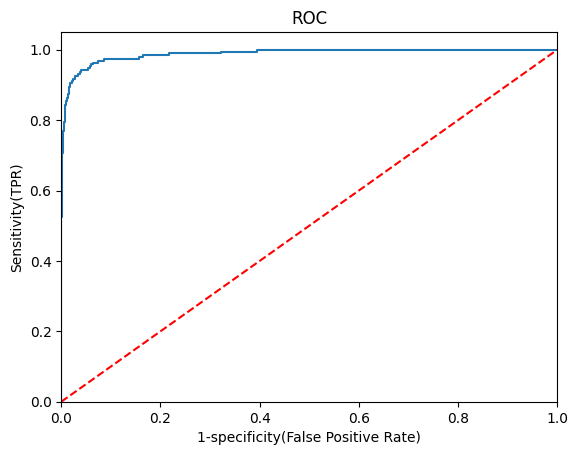

In [48]:
from sklearn.metrics import roc_auc_score,roc_curve
plt.figure()

auc_models=[
    {
         'label':'GradientBoostClassifier',
        'model':GradientBoostingClassifier(min_samples_split=2,max_depth=10,loss='log_loss',criterion='friedman_mse'),

        'auc':0.8921
    },
]

for algo in auc_models:
    model=algo['model']
    model.fit(x_train,y_train)
    y_prob = model.predict_proba(x_test)[:,1]

    fpr, tpr, thresholds = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    plt.plot(
        fpr,
        tpr,
        label='%s ROC (area=%0.2f)' % (algo['label'], auc)
    )
plt.plot([0,1],[0,1],'r--')
plt.xlim([0.0,1.0])
plt.ylim([0.0,1.05])
plt.xlabel('1-specificity(False Positive Rate)')
plt.ylabel('Sensitivity(TPR)')
plt.title('ROC')